IMPORTING THE DATASET

In [3]:
import os
import pandas as pd

data_path = '../data/ai4i2020.csv' if os.path.exists('../data/ai4i2020.csv') else 'data/ai4i2020.csv'
df = pd.read_csv(data_path)
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


DATA UNDERSTANING

In [5]:
print("First 5 Rows:")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

First 5 Rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


DATA CLEANING 

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [7]:
print("Duplicates count:", df.duplicated().sum())

Duplicates count: 0


In [8]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("Post-cleaning shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())
print("Remaining duplicates:", df.duplicated().sum())

Post-cleaning shape: (10000, 14)
Remaining nulls: 0
Remaining duplicates: 0


Exploratory Data Analysis (EDA)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


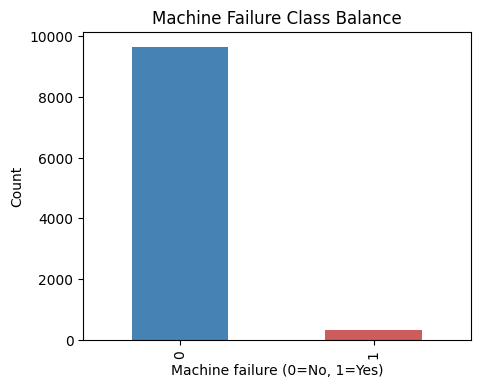

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [9]:
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
df['Machine failure'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Machine Failure Class Balance')
plt.xlabel('Machine failure (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

print(df['Machine failure'].value_counts(normalize=True) * 100)

Class Imbalance Finding

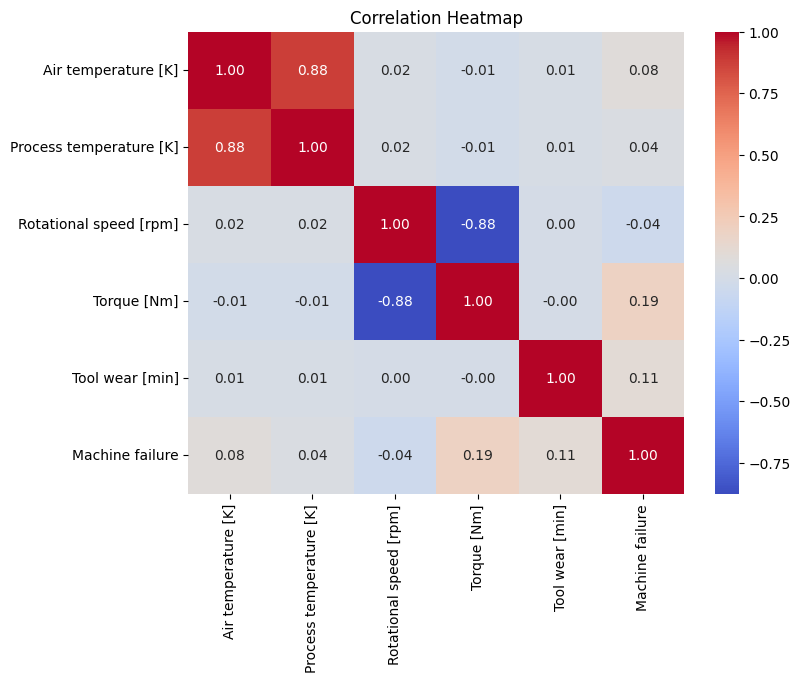

In [10]:
plt.figure(figsize=(8, 6))
cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
        'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Correlation Analysis Observations

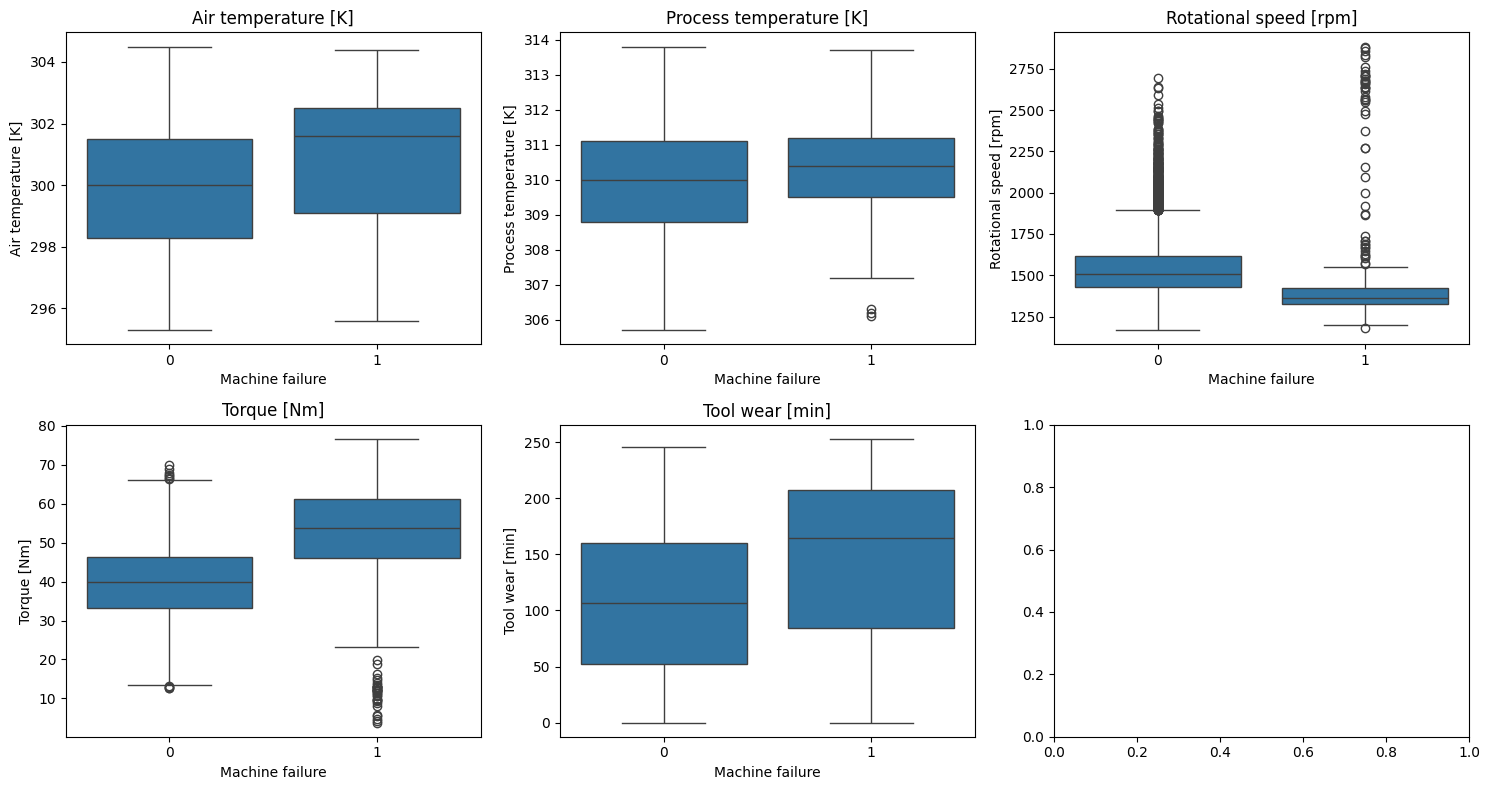

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feats = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
         'Torque [Nm]', 'Tool wear [min]']
for ax, col in zip(axes.flat, feats):
    sns.boxplot(data=df, x='Machine failure', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Feature Separation Findings

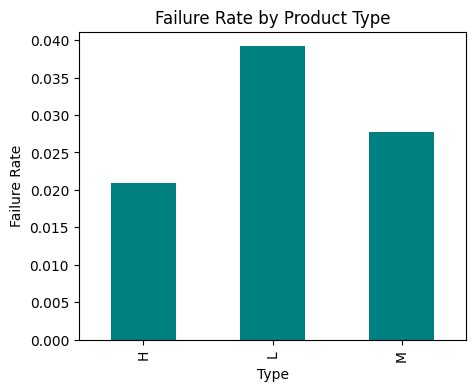

In [12]:
plt.figure(figsize=(5, 4))
df.groupby('Type')['Machine failure'].mean().plot(kind='bar', color='teal')
plt.title('Failure Rate by Product Type')
plt.ylabel('Failure Rate')
plt.show()

Feature Engineering & Imbalance Handling

In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler


df_fe = df.copy()

# TECHNIQUE 1: Removing Irrelevant Features & Target Leakage Columns
drop_cols = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_fe = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns], errors='ignore')

# TECHNIQUE 2: Handling Missing Values 
df_fe = df_fe.dropna()

# TECHNIQUE 3: Creating New Features
df_fe['Temp_Diff'] = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']

df_fe['Power_kW'] = (df_fe['Torque [Nm]'] * df_fe['Rotational speed [rpm]'] * (2 * np.pi / 60)) / 1000.0

df_fe['Wear_x_Torque'] = df_fe['Tool wear [min]'] * df_fe['Torque [Nm]']

#TECHNIQUE 4: Feature Binning / Quantization
df_fe['Wear_Level'] = pd.cut(df_fe['Tool wear [min]'], bins=[-1, 100, 200, 300], labels=['Low', 'Medium', 'High'])

# TECHNIQUE 5: Categorical Encoding (One-Hot Encoding)
df_fe = pd.get_dummies(df_fe, columns=['Type', 'Wear_Level'], drop_first=True)


print("Engineered dataset shape:", df_fe.shape)
df_fe.head()

Engineered dataset shape: (10000, 13)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Power_kW,Wear_x_Torque,Type_L,Type_M,Wear_Level_Medium,Wear_Level_High
0,298.1,308.6,1551,42.8,0,0,10.5,6.951591,0.0,False,True,False,False
1,298.2,308.7,1408,46.3,3,0,10.5,6.826723,138.9,True,False,False,False
2,298.1,308.5,1498,49.4,5,0,10.4,7.749388,247.0,True,False,False,False
3,298.2,308.6,1433,39.5,7,0,10.4,5.927505,276.5,True,False,False,False
4,298.2,308.7,1408,40.0,9,0,10.5,5.897817,360.0,True,False,False,False
